## CatNivo Dataset

### Preliminary assessment of # of kcat values in GEMs

## iML1515

In [1]:
# Import necessary modules
import sys
import os
sys.path.append(os.path.join('..', 'scripts'))

# Getting protein sequences with gene_mapper
from gene_mapper import map_gem_genes_to_uniprot

mapped_genes_iML1515 = map_gem_genes_to_uniprot('iML1515', 'E coli')


Using taxon ID: 83333
Model iML1515 loaded successfully.
Found 1516 unique gene IDs in model iML1515
Starting mapping of 1516 gene IDs to UniProt IDs...
Progress: 50/1516 genes processed
Progress: 100/1516 genes processed
Progress: 150/1516 genes processed
Progress: 200/1516 genes processed
Progress: 250/1516 genes processed
Progress: 300/1516 genes processed
Progress: 350/1516 genes processed
Progress: 400/1516 genes processed
Progress: 450/1516 genes processed
Progress: 500/1516 genes processed
Progress: 550/1516 genes processed
Progress: 600/1516 genes processed
Progress: 650/1516 genes processed
Progress: 700/1516 genes processed
Progress: 750/1516 genes processed
Progress: 800/1516 genes processed
Progress: 850/1516 genes processed
Progress: 900/1516 genes processed
Progress: 950/1516 genes processed
Progress: 1000/1516 genes processed
Progress: 1050/1516 genes processed
Progress: 1100/1516 genes processed
Progress: 1150/1516 genes processed
Progress: 1200/1516 genes processed
Pro

#### Using process_gpr

In [1]:
import cobra
import pandas as pd
import sys
sys.path.append(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset")

from GEM_dict import *

# Path to the UniProt mapping file
uniprot_mapping_file = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\results\iML1515_E coli_83333_UniProt.csv"

# Run process_gem
df_enzyme_info, enzyme_type_summary = process_gem("iML1515", uniprot_mapping_file)

# Print the enzyme type summary
print("Enzyme Type Summary:")
for enzyme_type, count in enzyme_type_summary.items():
    print(f"Type {enzyme_type}: {count} enzymes")
print(f'Total enzymes: {sum(enzyme_type_summary.values())}')

Model iML1515 loaded successfully from COBRA repository.
Enzyme Type Summary:
Type 1: 725 enzymes
Type 2: 461 enzymes
Type 3: 80 enzymes
Type 4: 250 enzymes
Total enzymes: 1516


In [2]:
import cobra
import pandas as pd
import sys
sys.path.append(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset")

from GEM_dict import *

# Path to the UniProt mapping file
uniprot_mapping_file = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\UniProt\iML1515_E coli_83333_UniProt.csv"

# Run process_gem
df_enzyme_info, enzyme_type_summary = process_gem("iML1515", uniprot_mapping_file)

# Print the enzyme type summary
print("Enzyme Type Summary:")
for enzyme_type, count in enzyme_type_summary.items():
    print(f"Type {enzyme_type}: {count} enzymes")
print(f'Total enzymes: {sum(enzyme_type_summary.values())}')

Model iML1515 loaded successfully from COBRA repository.
Enzyme Type Summary:
Type 1: 725 enzymes
Type 2: 461 enzymes
Type 3: 80 enzymes
Type 4: 250 enzymes
Total enzymes: 1516


In [2]:
# If considering each gene to represent an enzyme
# Count unique genes in the model 

from cobra.io import load_model

model = load_model("iML1515")
unique_genes = set(gene for reaction in model.reactions for gene in reaction.genes)
enzyme_count = len(unique_genes)
print(f"Total enzymes in the model: {enzyme_count}")

Total enzymes in the model: 1516


In [3]:
reaction_substrates_df = collect_substrates('iML1515')

Model iML1515 loaded successfully from COBRA repository.


In [4]:
kcat_df = calculate_kcats(df_enzyme_info, reaction_substrates_df)

In [6]:
print('kcats in iML1515: ',len(kcat_df))

kcats in iML1515:  9737


## Human GEM 

In [13]:
# Recon3D
# Will not use this, has 3D structure info but the annotations aren't as high quality and up to date

from cobra.io import read_sbml_model

model = read_sbml_model(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Recon3D.xml")
unique_genes = set(gene for reaction in model.reactions for gene in reaction.genes)
enzyme_count = len(unique_genes)
print(f"Total enzymes in the model: {enzyme_count}")
print(unique_genes)

Total enzymes in the model: 2248
{<Gene 1644_AT1 at 0x1fa38940190>, <Gene 55350_AT2 at 0x1fa38ac0190>, <Gene 4056_AT2 at 0x1fa388e01d0>, <Gene 23262_AT1 at 0x1fa38c60290>, <Gene 25902_AT1 at 0x1fa38840310>, <Gene 2593_AT2 at 0x1fa38860310>, <Gene 53905_AT2 at 0x1fa38920410>, <Gene 4715_AT1 at 0x1fa38be0410>, <Gene 8501_AT1 at 0x1fa38880510>, <Gene 9394_AT1 at 0x1fa38b40550>, <Gene 2876_AT1 at 0x1fa388e0650>, <Gene 4200_AT1 at 0x1fa38900650>, <Gene 1155_AT1 at 0x1fa38c00650>, <Gene 9058_AT1 at 0x1fa38a20690>, <Gene 5158_AT1 at 0x1fa38a606d0>, <Gene 9869_AT1 at 0x1fa38c40710>, <Gene 6120_AT1 at 0x1fa38b00750>, <Gene 5315_AT3 at 0x1fa38bc0750>, <Gene 3293_AT1 at 0x1fa38ae0810>, <Gene 79369_AT1 at 0x1fa38980850>, <Gene 5293_AT1 at 0x1fa38aa0850>, <Gene 55089_AT1 at 0x1fa389e0910>, <Gene 6557_AT1 at 0x1fa38a80990>, <Gene 4535_AT1 at 0x1fa38be09d0>, <Gene 84920_AT1 at 0x1fa38a00a50>, <Gene 2589_AT1 at 0x1fa38880a90>, <Gene 5277_AT2 at 0x1fa38a80ad0>, <Gene 4129_AT1 at 0x1fa38940b10>, <Gene 8

In [14]:
# Human-GEM
# Most up-to-date model

from cobra.io import read_sbml_model

model = read_sbml_model(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml")
unique_genes = set(gene for reaction in model.reactions for gene in reaction.genes)
enzyme_count = len(unique_genes)
print(f"Total enzymes in the model: {enzyme_count}")
print(unique_genes)

Total enzymes in the model: 2887
{<Gene ENSG00000131069 at 0x1fa39c20050>, <Gene ENSG00000129151 at 0x1fa39ca0050>, <Gene ENSG00000188089 at 0x1fa39040050>, <Gene ENSG00000112367 at 0x1fa39f00050>, <Gene ENSG00000142657 at 0x1fa39940090>, <Gene ENSG00000157326 at 0x1fa396c00d0>, <Gene ENSG00000147162 at 0x1fa398800d0>, <Gene ENSG00000092009 at 0x1fa3a2000d0>, <Gene ENSG00000167699 at 0x1fa39420110>, <Gene ENSG00000132744 at 0x1fa39bc0150>, <Gene ENSG00000054392 at 0x1fa3a440190>, <Gene ENSG00000112293 at 0x1fa39f20190>, <Gene ENSG00000197446 at 0x1fa38fe01d0>, <Gene ENSG00000170266 at 0x1fa39360210>, <Gene ENSG00000170890 at 0x1fa39340250>, <Gene ENSG00000197977 at 0x1fa38f402d0>, <Gene ENSG00000198964 at 0x1fa38e602d0>, <Gene ENSG00000135587 at 0x1fa39b202d0>, <Gene ENSG00000171320 at 0x1fa39320310>, <Gene ENSG00000259431 at 0x1fa38d80310>, <Gene ENSG00000168575 at 0x1fa393c0310>, <Gene ENSG00000139914 at 0x1fa399e0350>, <Gene ENSG00000135390 at 0x1fa39b203d0>, <Gene ENSG00000121310 a

In [3]:
import sys
import os
sys.path.append(os.path.join('..', 'scripts'))
from gene_mapper import *

# Convert to ENSPs
model = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml"
df_ENSP = ENSG_to_ENSP(model)


Loading model as path...


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Model C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml loaded successfully from path.


2 input query terms found no hit:	['ENSG00000263464', 'ENSG00000112096']


Created mapping file C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml_ENSP_to_ENSG.csv


In [1]:
import sys
import os
sys.path.append(os.path.join('..', 'scripts'))
from gene_mapper import *

# Query UniProt
ENSP_path = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\Human-GEM_ENSP.csv"
ENSP_df = pd.read_csv(ENSP_path)
mapped_df = map_ENSP_to_UniProt(ENSP_df)


Starting mapping of 21027 ENSP IDs to UniProt entries...
Progress: 50/21027 proteins processed
Progress: 100/21027 proteins processed
Progress: 150/21027 proteins processed
Progress: 200/21027 proteins processed
Progress: 250/21027 proteins processed
Progress: 300/21027 proteins processed
Progress: 350/21027 proteins processed
Progress: 400/21027 proteins processed
Progress: 450/21027 proteins processed
Progress: 500/21027 proteins processed
Progress: 550/21027 proteins processed
Progress: 600/21027 proteins processed
Progress: 650/21027 proteins processed
Progress: 700/21027 proteins processed
Progress: 750/21027 proteins processed
Progress: 800/21027 proteins processed
Progress: 850/21027 proteins processed
Progress: 900/21027 proteins processed
Progress: 950/21027 proteins processed
Progress: 1000/21027 proteins processed
Progress: 1050/21027 proteins processed
Progress: 1100/21027 proteins processed
Progress: 1150/21027 proteins processed
Progress: 1200/21027 proteins processed
Pro

In [1]:
import cobra
import pandas as pd
import sys
sys.path.append(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset")

from GEM_dict import *

# Paths
uniprot_mapping_file = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\Human1_9606_UniProt.csv"
model = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml"

# Process the model
df_enzyme_info, enzyme_summary = process_human_gem(model, uniprot_mapping_file)

# Print the enzyme type summary
print("Enzyme Type Summary:")
for enzyme_type, count in enzyme_summary.items():
    print(f"Type {enzyme_type}: {count} enzymes")
print(f'Total enzymes: {sum(enzyme_summary.values())}')

Output()

Loading model as path...
Model C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml loaded successfully from path.
Enzyme Type Summary:
Type 1: 988 enzymes
Type 2: 1683 enzymes
Type 3: 47 enzymes
Type 4: 169 enzymes
Total enzymes: 2887


In [57]:
from cobra.io import read_sbml_model
import cobra

modelread = read_sbml_model(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml")
unique_genes = set(gene for reaction in modelread.reactions for gene in reaction.genes)
enzyme_count = len(unique_genes)
print(f"Total genes in the model: {len(modelread.genes)}")
print(f"Total enzymes in the model: {enzyme_count}")

Total genes in the model: 2887
Total enzymes in the model: 2887


In [3]:
# Collect metabolites/substrates
substrates_df = collect_substrates(model,is_human_gem=True)

Loading model as path...
Model C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml loaded successfully from path.


In [4]:
# Calculate kcats
kcat_df = calculate_human_kcats(df_enzyme_info, substrates_df)
print('kcats in Human1: ',len(kcat_df))

kcats in Human1:  513845


In [5]:
output_file = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\results\Human1_enz_subs.csv"
kcat_df.to_csv(output_file, index=False)

## Yeast

In [ ]:
import sys
import os
sys.path.append(os.path.join('..', 'scripts'))

from gene_mapper import map_gem_genes_to_uniprot


model = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\yeast-GEM.xml"
mapped_genes_yeast = map_gem_genes_to_uniprot(model, 'yeast')

Output()

Using taxon ID: 4932 - Yeast


Loading model as path...
Model C:\Users\lyach\OneDrive - University of Toronto\GitHub\yeast-GEM\model\yeast-GEM.xml loaded successfully from path.
Found 1161 unique gene IDs in model C:\Users\lyach\OneDrive - University of Toronto\GitHub\yeast-GEM\model\yeast-GEM.xml
Starting mapping of 1161 gene IDs to UniProt IDs...
Progress: 50/1161 genes processed
Progress: 100/1161 genes processed
Progress: 150/1161 genes processed
Progress: 200/1161 genes processed
Progress: 250/1161 genes processed
Progress: 300/1161 genes processed
Progress: 350/1161 genes processed
Progress: 400/1161 genes processed
Progress: 450/1161 genes processed
Progress: 500/1161 genes processed
Progress: 550/1161 genes processed
Progress: 600/1161 genes processed
Progress: 650/1161 genes processed
Progress: 700/1161 genes processed
Progress: 750/1161 genes processed
Progress: 800/1161 genes processed
Progress: 850/1161 genes processed
Progress: 900/1161 genes processed
Progress: 950/1161 genes processed
Progress: 1000/1

In [9]:
import cobra
import pandas as pd
import sys
sys.path.append(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset")

from GEM_dict import *

# Path to the UniProt mapping file
uniprot_mapping_file = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\results\yeast_4932_UniProt.csv"

# Run process_gem
model = r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\yeast-GEM.xml"
df_enzyme_info, enzyme_type_summary = process_gem(model, uniprot_mapping_file)

# Print the enzyme type summary
print("Enzyme Type Summary:")
for enzyme_type, count in enzyme_type_summary.items():
    print(f"Type {enzyme_type}: {count} enzymes")
print(f'Total enzymes: {sum(enzyme_type_summary.values())}')

Loading model as path...
Model C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\yeast-GEM.xml loaded successfully from path.
Enzyme Type Summary:
Type 1: 607 enzymes
Type 2: 450 enzymes
Type 3: 46 enzymes
Type 4: 58 enzymes
Total enzymes: 1161


In [11]:
from cobra.io import read_sbml_model

modelread = read_sbml_model(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\yeast-GEM.xml")
unique_genes = set(gene for reaction in modelread.reactions for gene in reaction.genes)
enzyme_count = len(unique_genes)
print(f"Total enzymes in the model: {enzyme_count}")

Total enzymes in the model: 1161


In [12]:
reaction_substrates_df = collect_substrates(model)

Loading model as path...
Model C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\yeast-GEM.xml loaded successfully from path.


In [13]:
kcat_df = calculate_kcats(df_enzyme_info, reaction_substrates_df)

In [14]:
print('kcats in Yeast9: ',len(kcat_df))

kcats in Yeast9:  11046


## Dataset visualization

In [7]:
df_CPIPred = pd.read_csv(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\LiteratureDatasets\CPI_kcat_scrn.csv")
catpred1 = pd.read_csv(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\LiteratureDatasets\CatPred\kcat-random_test.csv")
catpred2 = pd.read_csv(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\LiteratureDatasets\CatPred\kcat-random_train.csv")
catpred3 = pd.read_csv(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\LiteratureDatasets\CatPred\kcat-random_trainval.csv")
catpred4 = pd.read_csv(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\LiteratureDatasets\CatPred\kcat-random_trainvaltest.csv")
catpred5 = pd.read_csv(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\LiteratureDatasets\CatPred\kcat-random_val.csv")


In [14]:
merged_df = pd.concat([catpred1, catpred2, catpred3, catpred4, catpred5], ignore_index=True)


In [16]:
merged_df = merged_df.drop_duplicates()

In [9]:
# Get the top 10 occurrences in the 'taxonomy_id' column
top_10_taxonomy_ids = catpred4['taxonomy_id'].value_counts().head(10)

# Display the results
print(top_10_taxonomy_ids)

taxonomy_id
9606.0     3218
562.0      1304
3702.0      818
10116.0     667
10090.0     555
9823.0      432
4932.0      361
1423.0      315
287.0       307
1773.0      284
Name: count, dtype: int64


In [17]:
# Get the top 10 occurrences in the 'taxonomy_id' column
top_taxonomy_ids = merged_df['taxonomy_id'].value_counts().head(30)

# Display the results
print(top_taxonomy_ids)

taxonomy_id
9606.0     3839
562.0      1528
3702.0      973
10116.0     773
10090.0     654
9823.0      506
4932.0      427
1423.0      380
287.0       364
1773.0      332
2287.0      328
303.0       285
9913.0      228
9986.0      225
4530.0      224
274.0       171
2336.0      161
5833.0      153
4577.0      147
7227.0      132
294.0       129
5061.0      129
1280.0      124
1772.0      119
90371.0     115
306.0       113
2190.0      110
2261.0      108
1351.0      104
3847.0      102
Name: count, dtype: int64


In [12]:
# Get the top 10 occurrences in the 'taxonomy_id' column
top_10_taxonomy_ids_CPIpred = df_CPIPred['organism'].value_counts().head(30)

# Display the results
print(top_10_taxonomy_ids_CPIpred)

organism
homo sapiens                      21289
escherichia coli                   4504
clostridium botulinum              1914
bos taurus                         1135
saccharomyces cerevisiae            950
rattus norvegicus                   793
pseudomonas aeruginosa              720
severe acute                        638
ricinus communis                    616
mycobacterium tuberculosis          616
equus caballus                      598
human immunodeficiency              586
sus scrofa                          390
pseudomonas sp.                     342
plasmodium falciparum               318
enterobacter cloacae                266
penicillium simplicissimum          242
klebsiella pneumoniae               239
citrobacter freundii                203
stenotrophomonas maltophilia        201
saccharolobus solfataricus          193
trypanosoma cruzi                   189
armoracia rusticana                 180
mus musculus                        171
geobacillus stearothermophilus 

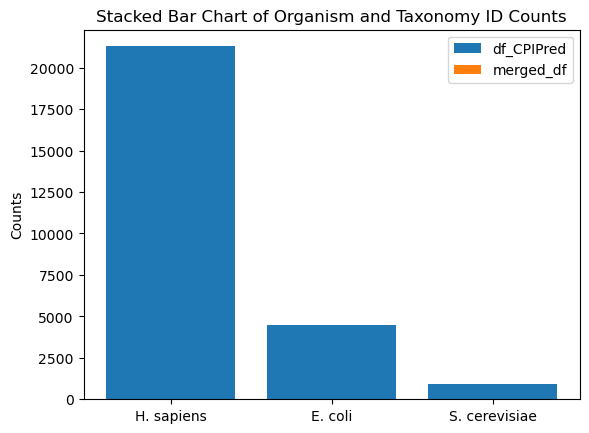

In [19]:
import matplotlib.pyplot as plt

# Count occurrences in df_CPIPred['organism']
organism_counts = df_CPIPred['organism'].value_counts()
h_sapiens_count = organism_counts.get('homo sapiens', 0)
e_coli_count = organism_counts.get('escherichia coli', 0)
s_cerevisiae_count = organism_counts.get('saccharomyces cerevisiae', 0)

# Count occurrences in merged_df['taxonomy_id']
taxonomy_counts = merged_df['taxonomy_id'].value_counts()
h_sapiens_tax_count = taxonomy_counts.get('3839', 0)
e_coli_tax_count = taxonomy_counts.get('562', 0)
s_cerevisiae_tax_count = taxonomy_counts.get('4932', 0)

# Data for the stacked bar chart
categories = ['H. sapiens', 'E. coli', 'S. cerevisiae']
df_CPIPred_counts = [h_sapiens_count, e_coli_count, s_cerevisiae_count]
merged_df_counts = [h_sapiens_tax_count, e_coli_tax_count, s_cerevisiae_tax_count]

# Create the stacked bar chart
fig, ax = plt.subplots()

ax.bar(categories, df_CPIPred_counts, label='df_CPIPred')
ax.bar(categories, merged_df_counts, bottom=df_CPIPred_counts, label='merged_df')

# Add labels and legend
ax.set_ylabel('Counts')
ax.set_title('Stacked Bar Chart of Organism and Taxonomy ID Counts')
ax.legend()

# Adjust y-axis limit
ax.set_ylim(0, max(df_CPIPred_counts) + max(merged_df_counts) + 1000)

# Show the plot
plt.show()

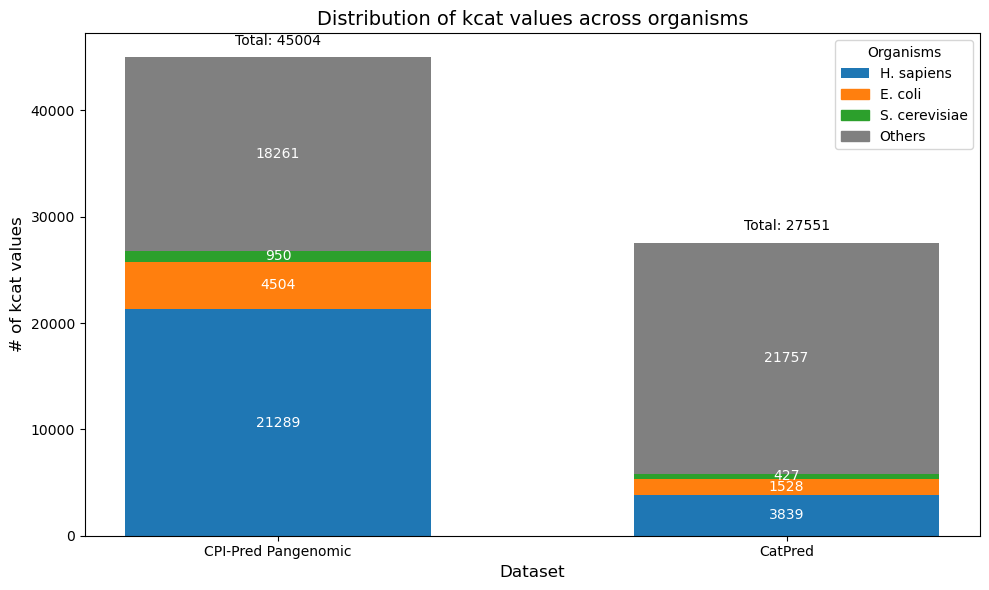

CPI-Pred Pangenomic Dataset:
  H. sapiens: 21289
  E. coli: 4504
  S. cerevisiae: 950
  Others: 18261
  Total: 45004

CatPred Dataset:
  H. sapiens: 3839
  E. coli: 1528
  S. cerevisiae: 427
  Others: 21757
  Total: 27551


In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Count organisms in df_CPIPred
cpipred_homo = len(df_CPIPred[df_CPIPred['organism'] == 'homo sapiens'])
cpipred_ecoli = len(df_CPIPred[df_CPIPred['organism'] == 'escherichia coli'])
cpipred_yeast = len(df_CPIPred[df_CPIPred['organism'] == 'saccharomyces cerevisiae'])
cpipred_others = len(df_CPIPred) - (cpipred_homo + cpipred_ecoli + cpipred_yeast)

cpipred_counts = {
    'H. sapiens': cpipred_homo,
    'E. coli': cpipred_ecoli,
    'S. cerevisiae': cpipred_yeast,
    'Others': cpipred_others
}

# Count taxonomy IDs in merged_df
catpred_homo = len(merged_df[merged_df['taxonomy_id'] == 9606])
catpred_ecoli = len(merged_df[merged_df['taxonomy_id'] == 562])
catpred_yeast = len(merged_df[merged_df['taxonomy_id'] == 4932])
catpred_others = len(merged_df) - (catpred_homo + catpred_ecoli + catpred_yeast)

catpred_counts = {
    'H. sapiens': catpred_homo,
    'E. coli': catpred_ecoli,
    'S. cerevisiae': catpred_yeast,
    'Others': catpred_others
}

# Prepare data for plotting
datasets = ['CPI-Pred Pangenomic', 'CatPred']
organisms = ['H. sapiens', 'E. coli', 'S. cerevisiae', 'Others']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#808080']  # Blue, Orange, Green, Red

# Create the data arrays
cpipred_values = [cpipred_counts[org] for org in organisms]
catpred_values = [catpred_counts[org] for org in organisms]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Bar positions
x = np.arange(len(datasets))
width = 0.6

# Create stacked bars
bottom_cpipred = 0
bottom_catpred = 0

bars = []
for i, organism in enumerate(organisms):
    # CPI-Pred bar
    bar1 = ax.bar(x[0], cpipred_values[i], width, bottom=bottom_cpipred, 
                  color=colors[i], label=organism if i == 0 else "")
    bottom_cpipred += cpipred_values[i]
    
    # CatPred bar
    bar2 = ax.bar(x[1], catpred_values[i], width, bottom=bottom_catpred, 
                  color=colors[i])
    bottom_catpred += catpred_values[i]
    
    # Store bars for legend
    if i == 0:
        bars.append(bar1[0])

# Add remaining organisms to bars list for legend
for i in range(1, len(organisms)):
    bars.append(plt.Rectangle((0,0),1,1, color=colors[i]))

# Customize the plot
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('# of kcat values', fontsize=12)
ax.set_title('Distribution of kcat values across organisms', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(datasets)

# Add legend
ax.legend(bars, organisms, title='Organisms', loc='upper right')

# Add value labels on bars
def add_value_labels(ax, x_pos, values, bottom_values):
    cumulative = 0
    for i, v in enumerate(values):
        if v > 0:  # Only add label if value is greater than 0
            ax.text(x_pos, cumulative + v/2, str(v), 
                   ha='center', va='center', color='white')
        cumulative += v

# Add labels for both bars
add_value_labels(ax, x[0], cpipred_values, [0])
add_value_labels(ax, x[1], catpred_values, [0])

# Add total height labels on top of bars
total_cpipred = sum(cpipred_values)
total_catpred = sum(catpred_values)
ax.text(x[0], total_cpipred + max(total_cpipred, total_catpred) * 0.02, 
        f'Total: {total_cpipred}', ha='center', va='bottom')
ax.text(x[1], total_catpred + max(total_cpipred, total_catpred) * 0.02, 
        f'Total: {total_catpred}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print summary statistics
print("CPI-Pred Pangenomic Dataset:")
for org, count in cpipred_counts.items():
    print(f"  {org}: {count}")
print(f"  Total: {total_cpipred}")

print("\nCatPred Dataset:")
for org, count in catpred_counts.items():
    print(f"  {org}: {count}")
print(f"  Total: {total_catpred}")

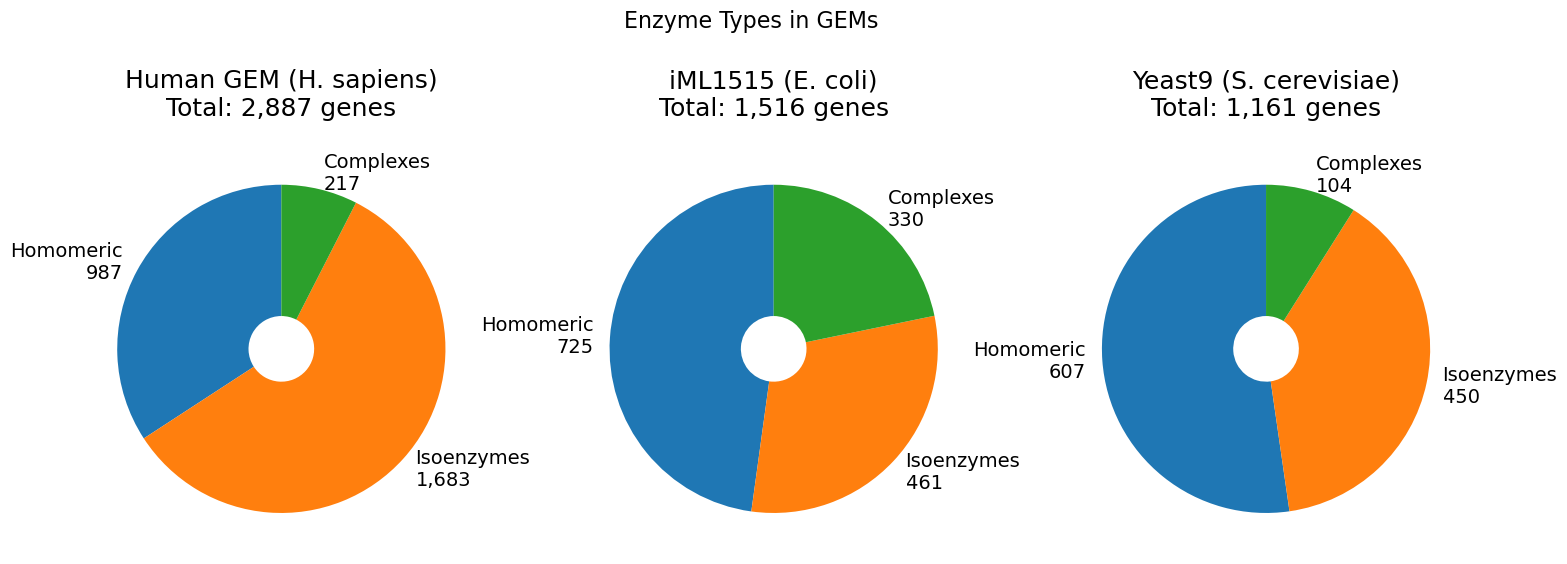

Enzyme Type Distribution Summary:

Human GEM (H. sapiens) (Total: 2,887 enzymes):
----------------------------------------
  Homomeric   :   987
  Isoenzymes  : 1,683
  Complexes   :   217

iML1515 (E. coli) (Total: 1,516 enzymes):
----------------------------------------
  Homomeric   :   725
  Isoenzymes  :   461
  Complexes   :   330

Yeast9 (S. cerevisiae) (Total: 1,161 enzymes):
----------------------------------------
  Homomeric   :   607
  Isoenzymes  :   450
  Complexes   :   104


In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each organism
organisms_data = {
    'Human GEM (H. sapiens)': {
        'total': 2887,
        'Homomeric': 34.2,
        'Isoenzymes': 58.3,
        'Complexes': 7.5
    },
    'iML1515 (E. coli)': {
        'total': 1516,
        'Homomeric': 47.8,
        'Isoenzymes': 30.4,
        'Complexes': 21.8
    },
    'Yeast9 (S. cerevisiae)': {
        'total': 1161,
        'Homomeric': 52.3,
        'Isoenzymes': 38.8,
        'Complexes': 9.0
    }
}

# Calculate actual numbers from percentages
enzyme_counts = {}
for organism, data in organisms_data.items():
    total = data['total']
    enzyme_counts[organism] = {
        'Homomeric': round(total * data['Homomeric'] / 100),
        'Isoenzymes': round(total * data['Isoenzymes'] / 100),
        'Complexes': round(total * data['Complexes'] / 100)
    }

# Colors for enzyme types
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
enzyme_types = ['Homomeric', 'Isoenzymes', 'Complexes']

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Enzyme Types in GEMs', fontsize=16, y=1.06)

# Create pie charts for each organism
for idx, (organism, ax) in enumerate(zip(organisms_data.keys(), axes)):
    # Get data for this organism
    counts = [enzyme_counts[organism][enzyme_type] for enzyme_type in enzyme_types]
    percentages = [organisms_data[organism][enzyme_type] for enzyme_type in enzyme_types]
    
    # Create labels with both count and percentage
    labels = [f'{enzyme_type}\n{count:,}' 
              for enzyme_type, count, pct in zip(enzyme_types, counts, percentages)]
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(counts, labels=labels, colors=colors, 
                                     autopct='', startangle=90, 
                                     wedgeprops=dict(width=0.8))
    
    # Customize the appearance
    ax.set_title(f'{organism}\nTotal: {organisms_data[organism]["total"]:,} genes', 
                fontsize=18, pad=20)
    
    # Adjust text properties
    for text in texts:
        text.set_fontsize(14)


plt.show()

# Print summary statistics
print("Enzyme Type Distribution Summary:")
print("=" * 60)
for organism in organisms_data.keys():
    print(f"\n{organism} (Total: {organisms_data[organism]['total']:,} enzymes):")
    print("-" * 40)
    for enzyme_type in enzyme_types:
        count = enzyme_counts[organism][enzyme_type]
        percentage = organisms_data[organism][enzyme_type]
        print(f"  {enzyme_type:12s}: {count:5,}")


## Counting enzymes

### E coli

In [77]:
import re 
from sympy import symbols, sympify 
from sympy.logic.boolalg import to_dnf
import warnings
warnings.filterwarnings('ignore')
 
def count_enzyme_types(model): 
    """ 
    Returns a dict with the number of: 
      • isoenzyme rules      (gene1 OR gene2 …) 
      • enzyme complexes     (geneA AND geneB …, ≥2 different genes) 
      • homomeric enzymes    (single gene or geneX AND geneX …) 
    Parameters 
    ---------- 
    model : cobra.Model  (already loaded with cobrapy) 
    """ 
    counts = {"isoenzymes": 0, "complexes": 0, "homomeric": 0, 'error':0} 
 
    for rxn in model.reactions: 
        print(rxn)
        gpr = rxn.gene_reaction_rule.strip()
        print(gpr)
        if not gpr:             # skip reactions without a GPR 
            continue 
            
        # --- 1. First normalize all logic operators --------------------------- 
        # Convert all operator variations to & and | with proper spacing
        expr = gpr.replace(" and ", " & ").replace(" or ", " | ") 
        expr = re.sub(r'\b(?:and|AND)\b', ' & ', expr) 
        expr = re.sub(r'\b(?:or|OR)\b', ' | ', expr) 
        expr = re.sub(r'\s+', ' ', expr).strip()  # Clean whitespace
        
        # --- 2. Find actual gene IDs (excluding operators) ------------------- 
        genes = []
        for token in re.findall(r'[A-Za-z0-9_.-]+', expr):
            # Skip tokens that are actually operators
            if token.lower() not in ('and', 'or', '&', '|'):
                genes.append(token)
        
        genes = sorted(set(genes))
        if not genes: 
            continue 
            
        # Create symbol mapping for actual genes only
        sym_map = {g: f"g{idx}" for idx, g in enumerate(genes)} 
        
        # --- 3. Replace gene IDs with symbols in the expression --------------
        for gene, sym in sym_map.items(): 
            expr = re.sub(rf'\b{re.escape(gene)}\b', sym, expr) 
        
        # --- 4. Clean up and normalize the expression -----------------------
        # Ensure all operators have spaces on both sides
        expr = re.sub(r'(\s*)&(\s*)', r' & ', expr)
        expr = re.sub(r'(\s*)\|(\s*)', r' | ', expr)
        
        # Fix implicit AND operations
        expr = re.sub(r'(\bg\d+\b)\s+(\bg\d+\b)', r'\1 & \2', expr)  # g0 g1 -> g0 & g1
        expr = re.sub(r'(\bg\d+\b)\s*\(', r'\1 & (', expr)          # g0(... -> g0 & (...
        expr = re.sub(r'\)\s*(\bg\d+\b)', r') & \1', expr)          # )g1 -> ) & g1
        expr = re.sub(r'\)\s*\(', r') & (', expr)                   # )( -> ) & (
        
        # Final spacing cleanup
        expr = re.sub(r'\s+', ' ', expr).strip()
        
        # --- 5. Process and classify the Boolean expression ----------------
        try:
            locals_dict = {v: symbols(v) for v in sym_map.values()} 
            
            # Important: set simplify=False to prevent over-simplification
            sympy_expr = sympify(expr, locals=locals_dict)
            dnf = to_dnf(sympy_expr, simplify=False)
            print(dnf)
            
            # Classify the expression with improved logic
            if "or" in gpr.lower() and "(" in gpr and ")" in gpr:
                # This is a special case for expressions like "b3857 or (b3857 and b3856)"
                # which are isoenzymes with one option being a complex
                counts["isoenzymes"] += 1
            elif dnf.func.__name__ == "Or":  
                # Standard ≥1 isoenzyme alternative
                counts["isoenzymes"] += 1 
            elif dnf.func.__name__ == "Symbol":  
                # Single gene
                counts["homomeric"] += 1 
            elif dnf.func.__name__ == "And": 
                genes_in_term = {str(arg) for arg in dnf.args} 
                if len(genes_in_term) == 1:  
                    # geneX & geneX → homomer
                    counts["homomeric"] += 1 
                else:  
                    # geneA & geneB … → complex
                    counts["complexes"] += 1
            else:
                # For any other case, examine the original GPR for 'or'
                if " or " in gpr.lower() or " | " in expr:
                    counts["isoenzymes"] += 1
                else:
                    counts["homomeric"] += 1
                
        except Exception as e:
            counts["error"] += 1
            print(f"Error parsing expression: '{expr}' from original: '{gpr}'")
            # print(f"Genes: {genes}")
            # print(f"Symbol map: {sym_map}")
            # print(f"Error: {str(e)}")
    
    return counts 
 

from cobra.io import load_model   # or read_sbml_model 
 
model = load_model("iML1515")     # example: E. coli core 
results = count_enzyme_types(model)
print(results) 
print('total enzymes: ', sum(results.values()))

CYTDK2: cytd_c + gtp_c --> cmp_c + gdp_c + h_c
b2066
g0
XPPT: prpp_c + xan_c --> ppi_c + xmp_c
b0238
g0
HXPRT: hxan_c + prpp_c --> imp_c + ppi_c
b0238 or b0125
g0 | g1
NDPK5: atp_c + dgdp_c <=> adp_c + dgtp_c
b0474 or b2518
g0 | g1
SHK3Dr: 3dhsk_c + h_c + nadph_c <=> nadp_c + skm_c
b3281 or b1692
g0 | g1
NDPK6: atp_c + dudp_c <=> adp_c + dutp_c
b0474 or b2518
g0 | g1
NDPK8: atp_c + dadp_c <=> adp_c + datp_c
b0474 or b2518
g0 | g1
DHORTS: dhor__S_c + h2o_c <=> cbasp_c + h_c
b1062
g0
OMPDC: h_c + orot5p_c --> co2_c + ump_c
b1281
g0
PYNP2r: pi_c + uri_c <=> r1p_c + ura_c
b3831
g0
G5SD: glu5p_c + h_c + nadph_c --> glu5sa_c + nadp_c + pi_c
b0243
g0
CS: accoa_c + h2o_c + oaa_c --> cit_c + coa_c + h_c
b0720
g0
ICDHyr: icit_c + nadp_c <=> akg_c + co2_c + nadph_c
b1136
g0
ALATA_L2: ala__L_c + pydx5p_c --> pyam5p_c + pyr_c
b0870 or b2551
g0 | g1
DURIPP: duri_c + pi_c <=> 2dr1p_c + ura_c
b4382 or b4384
g0 | g1
ACALD: acald_c + coa_c + nad_c <=> accoa_c + h_c + nadh_c
b0351 or b1241
g0 | g1
PTRCTA

In [ ]:
import re 
from sympy import symbols, sympify 
from sympy.logic.boolalg import to_dnf
import warnings
warnings.filterwarnings('ignore')
 
def count_enzyme_types(model): 
    """ 
    Returns a dict with the number of: 
      • isoenzyme rules      (gene1 OR gene2 …) 
      • enzyme complexes     (geneA AND geneB …, ≥2 different genes) 
      • homomeric enzymes    (single gene or geneX AND geneX …) 
    Parameters 
    ---------- 
    model : cobra.Model  (already loaded with cobrapy) 
    """ 
    counts = {"isoenzymes": 0, "complexes": 0, "homomeric": 0, 'error':0} 
 
    for rxn in model.reactions: 
        print(rxn)
        gpr = rxn.gene_reaction_rule.strip()
        print(gpr)
        if not gpr:             # skip reactions without a GPR 
            continue 
            
        # --- 1. First normalize all logic operators --------------------------- 
        # Convert all operator variations to & and | with proper spacing
        expr = gpr.replace(" and ", " & ").replace(" or ", " | ") 
        expr = re.sub(r'\b(?:and|AND)\b', ' & ', expr) 
        expr = re.sub(r'\b(?:or|OR)\b', ' | ', expr) 
        expr = re.sub(r'\s+', ' ', expr).strip()  # Clean whitespace
        
        # --- 2. Find actual gene IDs (excluding operators) ------------------- 
        genes = []
        for token in re.findall(r'[A-Za-z0-9_.-]+', expr):
            # Skip tokens that are actually operators
            if token.lower() not in ('and', 'or', '&', '|'):
                genes.append(token)
        
        genes = sorted(set(genes))
        if not genes: 
            continue 
            
        # Create symbol mapping for actual genes only
        sym_map = {g: f"g{idx}" for idx, g in enumerate(genes)} 
        
        # --- 3. Replace gene IDs with symbols in the expression --------------
        for gene, sym in sym_map.items(): 
            expr = re.sub(rf'\b{re.escape(gene)}\b', sym, expr) 
        
        # --- 4. Clean up and normalize the expression -----------------------
        # Ensure all operators have spaces on both sides
        expr = re.sub(r'(\s*)&(\s*)', r' & ', expr)
        expr = re.sub(r'(\s*)\|(\s*)', r' | ', expr)
        
        # Fix implicit AND operations
        expr = re.sub(r'(\bg\d+\b)\s+(\bg\d+\b)', r'\1 & \2', expr)  # g0 g1 -> g0 & g1
        expr = re.sub(r'(\bg\d+\b)\s*\(', r'\1 & (', expr)          # g0(... -> g0 & (...
        expr = re.sub(r'\)\s*(\bg\d+\b)', r') & \1', expr)          # )g1 -> ) & g1
        expr = re.sub(r'\)\s*\(', r') & (', expr)                   # )( -> ) & (
        
        # Final spacing cleanup
        expr = re.sub(r'\s+', ' ', expr).strip()
        
        # --- 5. Process and classify the Boolean expression ----------------
        try:
            locals_dict = {v: symbols(v) for v in sym_map.values()} 
            
            # Important: set simplify=False to prevent over-simplification
            sympy_expr = sympify(expr, locals=locals_dict)
            dnf = to_dnf(sympy_expr, simplify=False)
            print(dnf)
            
            # Classify the expression with improved logic
            if "or" in gpr.lower() and "(" in gpr and ")" in gpr:
                # This is a special case for expressions like "b3857 or (b3857 and b3856)"
                # which are isoenzymes with one option being a complex
                counts["isoenzymes"] += 1
            elif dnf.func.__name__ == "Or":  
                # Standard ≥1 isoenzyme alternative
                counts["isoenzymes"] += 1 
            elif dnf.func.__name__ == "Symbol":  
                # Single gene
                counts["homomeric"] += 1 
            elif dnf.func.__name__ == "And": 
                genes_in_term = {str(arg) for arg in dnf.args} 
                if len(genes_in_term) == 1:  
                    # geneX & geneX → homomer
                    counts["homomeric"] += 1 
                else:  
                    # geneA & geneB … → complex
                    counts["complexes"] += 1
            else:
                # For any other case, examine the original GPR for 'or'
                if " or " in gpr.lower() or " | " in expr:
                    counts["isoenzymes"] += 1
                else:
                    counts["homomeric"] += 1
                
        except Exception as e:
            counts["error"] += 1
            print(f"Error parsing expression: '{expr}' from original: '{gpr}'")
            # print(f"Genes: {genes}")
            # print(f"Symbol map: {sym_map}")
            # print(f"Error: {str(e)}")
    
    return counts 
 

from cobra.io import load_model   # or read_sbml_model 
 
model = load_model("iML1515")     # example: E. coli core 
results = count_enzyme_types(model)
print(results) 
print('total enzymes: ', sum(results.values()))

In [84]:
modelyeast = read_sbml_model(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml")
for rxn in modelyeast.reactions:
    print(f"{rxn.id}: {rxn.gene_reaction_rule}")


MAR03905: ENSG00000147576 or ENSG00000172955 or ENSG00000180011 or ENSG00000187758 or ENSG00000196344 or ENSG00000196616 or ENSG00000197894 or ENSG00000198099 or ENSG00000248144
MAR03907: ENSG00000117448
MAR04097: ENSG00000131069
MAR04099: ENSG00000111058 or ENSG00000154930
MAR04108: ENSG00000131069
MAR04133: ENSG00000131069
MAR04281: ENSG00000111716 or ENSG00000134333
MAR04388: ENSG00000111716 or ENSG00000134333 or ENSG00000166796 or ENSG00000166800 or ENSG00000171989
MAR04283: ENSG00000006534 or ENSG00000108602 or ENSG00000132746 or ENSG00000184254
MAR08357: ENSG00000072210 or ENSG00000111275 or ENSG00000137124 or ENSG00000143149 or ENSG00000164904
MAR04379: ENSG00000067057 or ENSG00000141959 or ENSG00000152556
MAR04301: ENSG00000067057 or ENSG00000141959 or ENSG00000152556
MAR04355: ENSG00000109107 or ENSG00000136872
MAR04358: ENSG00000067225 or ENSG00000143627
MAR04360: ENSG00000180011
MAR04363: ENSG00000074800 or ENSG00000108515 or ENSG00000111674
MAR04365: ENSG00000164708 or ENSG

### Yeast

In [86]:
import re 
from sympy import symbols, sympify 
from sympy.logic.boolalg import to_dnf
import warnings
warnings.filterwarnings('ignore')
 
def count_enzyme_types(model): 
    """ 
    Returns a dict with the number of: 
      • isoenzyme rules      (gene1 OR gene2 …) 
      • enzyme complexes     (geneA AND geneB …, ≥2 different genes) 
      • homomeric enzymes    (single gene or geneX AND geneX …) 
    Parameters 
    ---------- 
    model : cobra.Model  (already loaded with cobrapy) 
    """ 
    counts = {"isoenzymes": 0, "complexes": 0, "homomeric": 0, 'error':0} 
 
    for rxn in model.reactions: 
        #print(rxn)
        gpr = rxn.gene_reaction_rule.strip()
        #print(gpr)
        if not gpr:             # skip reactions without a GPR 
            continue 
            
        # --- 1. First normalize all logic operators --------------------------- 
        # Convert all operator variations to & and | with proper spacing
        expr = gpr.replace(" and ", " & ").replace(" or ", " | ") 
        expr = re.sub(r'\b(?:and|AND)\b', ' & ', expr) 
        expr = re.sub(r'\b(?:or|OR)\b', ' | ', expr) 
        expr = re.sub(r'\s+', ' ', expr).strip()  # Clean whitespace
        
        # --- 2. Find actual gene IDs (excluding operators) ------------------- 
        genes = []
        for token in re.findall(r'[A-Za-z0-9_.-]+', expr):
            # Skip tokens that are actually operators
            if token.lower() not in ('and', 'or', '&', '|'):
                genes.append(token)
        
        genes = sorted(set(genes))
        if not genes: 
            continue 
            
        # Create symbol mapping for actual genes only
        sym_map = {g: f"g{idx}" for idx, g in enumerate(genes)} 
        
        # --- 3. Replace gene IDs with symbols in the expression --------------
        for gene, sym in sym_map.items(): 
            expr = re.sub(rf'\b{re.escape(gene)}\b', sym, expr) 
        
        # --- 4. Clean up and normalize the expression -----------------------
        # Ensure all operators have spaces on both sides
        expr = re.sub(r'(\s*)&(\s*)', r' & ', expr)
        expr = re.sub(r'(\s*)\|(\s*)', r' | ', expr)
        
        # Fix implicit AND operations
        expr = re.sub(r'(\bg\d+\b)\s+(\bg\d+\b)', r'\1 & \2', expr)  # g0 g1 -> g0 & g1
        expr = re.sub(r'(\bg\d+\b)\s*\(', r'\1 & (', expr)          # g0(... -> g0 & (...
        expr = re.sub(r'\)\s*(\bg\d+\b)', r') & \1', expr)          # )g1 -> ) & g1
        expr = re.sub(r'\)\s*\(', r') & (', expr)                   # )( -> ) & (
        
        # Final spacing cleanup
        expr = re.sub(r'\s+', ' ', expr).strip()
        
        # --- 5. Process and classify the Boolean expression ----------------
        try:
            locals_dict = {v: symbols(v) for v in sym_map.values()} 
            
            # Important: set simplify=False to prevent over-simplification
            sympy_expr = sympify(expr, locals=locals_dict)
            dnf = to_dnf(sympy_expr, simplify=False)
            #print(dnf)
            
            # Classify the expression with improved logic
            if "or" in gpr.lower() and "(" in gpr and ")" in gpr:
                # This is a special case for expressions like "b3857 or (b3857 and b3856)"
                # which are isoenzymes with one option being a complex
                counts["isoenzymes"] += 1
            elif dnf.func.__name__ == "Or":  
                # Standard ≥1 isoenzyme alternative
                counts["isoenzymes"] += 1 
            elif dnf.func.__name__ == "Symbol":  
                # Single gene
                counts["homomeric"] += 1 
            elif dnf.func.__name__ == "And": 
                genes_in_term = {str(arg) for arg in dnf.args} 
                if len(genes_in_term) == 1:  
                    # geneX & geneX → homomer
                    counts["homomeric"] += 1 
                else:  
                    # geneA & geneB … → complex
                    counts["complexes"] += 1
            else:
                # For any other case, examine the original GPR for 'or'
                if " or " in gpr.lower() or " | " in expr:
                    counts["isoenzymes"] += 1
                else:
                    counts["homomeric"] += 1
                
        except Exception as e:
            counts["error"] += 1
            print(f"Error parsing expression: '{expr}' from original: '{gpr}'")
            print(f"Genes: {genes}")
            print(f"Symbol map: {sym_map}")
            print(f"Error: {str(e)}")
    
    return counts 
 

from cobra.io import load_model   # or read_sbml_model 
 
modelyeast = read_sbml_model(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\yeast-GEM.xml")
results = count_enzyme_types(modelyeast)
print(results) 
print('total enzymes: ', sum(results.values()))

Error parsing expression: 'g0 | g1 | g1-A' from original: 'YER056C or YER060W or YER060W-A'
Genes: ['YER056C', 'YER060W', 'YER060W-A']
Symbol map: {'YER056C': 'g0', 'YER060W': 'g1', 'YER060W-A': 'g2'}
Error: unsupported operand type(s) for |: 'Or' and 'Add'
Error parsing expression: 'g0 | g1 | g1-A | g3' from original: 'YER056C or YER060W or YER060W-A or YGL186C'
Genes: ['YER056C', 'YER060W', 'YER060W-A', 'YGL186C']
Symbol map: {'YER056C': 'g0', 'YER060W': 'g1', 'YER060W-A': 'g2', 'YGL186C': 'g3'}
Error: unsupported operand type(s) for |: 'Or' and 'Add'
Error parsing expression: 'g0 | g1 | g1-A' from original: 'YER056C or YER060W or YER060W-A'
Genes: ['YER056C', 'YER060W', 'YER060W-A']
Symbol map: {'YER056C': 'g0', 'YER060W': 'g1', 'YER060W-A': 'g2'}
Error: unsupported operand type(s) for |: 'Or' and 'Add'
{'isoenzymes': 588, 'complexes': 159, 'homomeric': 1959, 'error': 3}
total enzymes:  2709


### Human-GEM

In [85]:
import re 
from sympy import symbols, sympify 
from sympy.logic.boolalg import to_dnf
import warnings
warnings.filterwarnings('ignore')
 
def count_enzyme_types(model): 
    """ 
    Returns a dict with the number of: 
      • isoenzyme rules      (gene1 OR gene2 …) 
      • enzyme complexes     (geneA AND geneB …, ≥2 different genes) 
      • homomeric enzymes    (single gene or geneX AND geneX …) 
    Parameters 
    ---------- 
    model : cobra.Model  (already loaded with cobrapy) 
    """ 
    counts = {"isoenzymes": 0, "complexes": 0, "homomeric": 0, 'error':0} 
 
    for rxn in model.reactions: 
        #print(rxn)
        gpr = rxn.gene_reaction_rule.strip()
        #print(gpr)
        if not gpr:             # skip reactions without a GPR 
            continue 
            
        # --- 1. First normalize all logic operators --------------------------- 
        # Convert all operator variations to & and | with proper spacing
        expr = gpr.replace(" and ", " & ").replace(" or ", " | ") 
        expr = re.sub(r'\b(?:and|AND)\b', ' & ', expr) 
        expr = re.sub(r'\b(?:or|OR)\b', ' | ', expr) 
        expr = re.sub(r'\s+', ' ', expr).strip()  # Clean whitespace
        
        # --- 2. Find actual gene IDs (excluding operators) ------------------- 
        genes = []
        for token in re.findall(r'[A-Za-z0-9_.-]+', expr):
            # Skip tokens that are actually operators
            if token.lower() not in ('and', 'or', '&', '|'):
                genes.append(token)
        
        genes = sorted(set(genes))
        if not genes: 
            continue 
            
        # Create symbol mapping for actual genes only
        sym_map = {g: f"g{idx}" for idx, g in enumerate(genes)} 
        
        # --- 3. Replace gene IDs with symbols in the expression --------------
        for gene, sym in sym_map.items(): 
            expr = re.sub(rf'\b{re.escape(gene)}\b', sym, expr) 
        
        # --- 4. Clean up and normalize the expression -----------------------
        # Ensure all operators have spaces on both sides
        expr = re.sub(r'(\s*)&(\s*)', r' & ', expr)
        expr = re.sub(r'(\s*)\|(\s*)', r' | ', expr)
        
        # Fix implicit AND operations
        expr = re.sub(r'(\bg\d+\b)\s+(\bg\d+\b)', r'\1 & \2', expr)  # g0 g1 -> g0 & g1
        expr = re.sub(r'(\bg\d+\b)\s*\(', r'\1 & (', expr)          # g0(... -> g0 & (...
        expr = re.sub(r'\)\s*(\bg\d+\b)', r') & \1', expr)          # )g1 -> ) & g1
        expr = re.sub(r'\)\s*\(', r') & (', expr)                   # )( -> ) & (
        
        # Final spacing cleanup
        expr = re.sub(r'\s+', ' ', expr).strip()
        
        # --- 5. Process and classify the Boolean expression ----------------
        try:
            locals_dict = {v: symbols(v) for v in sym_map.values()} 
            
            # Important: set simplify=False to prevent over-simplification
            sympy_expr = sympify(expr, locals=locals_dict)
            dnf = to_dnf(sympy_expr, simplify=False)
            #print(dnf)
            
            # Classify the expression with improved logic
            if "or" in gpr.lower() and "(" in gpr and ")" in gpr:
                # This is a special case for expressions like "b3857 or (b3857 and b3856)"
                # which are isoenzymes with one option being a complex
                counts["isoenzymes"] += 1
            elif dnf.func.__name__ == "Or":  
                # Standard ≥1 isoenzyme alternative
                counts["isoenzymes"] += 1 
            elif dnf.func.__name__ == "Symbol":  
                # Single gene
                counts["homomeric"] += 1 
            elif dnf.func.__name__ == "And": 
                genes_in_term = {str(arg) for arg in dnf.args} 
                if len(genes_in_term) == 1:  
                    # geneX & geneX → homomer
                    counts["homomeric"] += 1 
                else:  
                    # geneA & geneB … → complex
                    counts["complexes"] += 1
            else:
                # For any other case, examine the original GPR for 'or'
                if " or " in gpr.lower() or " | " in expr:
                    counts["isoenzymes"] += 1
                else:
                    counts["homomeric"] += 1
                
        except Exception as e:
            counts["error"] += 1
            print(f"Error parsing expression: '{expr}' from original: '{gpr}'")
            print(f"Genes: {genes}")
            print(f"Symbol map: {sym_map}")
            print(f"Error: {str(e)}")
    
    return counts 
 

from cobra.io import load_model   # or read_sbml_model 
 
modelhuman = read_sbml_model(r"C:\Users\lyach\OneDrive - University of Toronto\GitHub\CatNivoDataset\data\GEMs\Human-GEM.xml")
results = count_enzyme_types(modelhuman)
print(results) 
print('total enzymes: ', sum(results.values()))

{'isoenzymes': 3988, 'complexes': 577, 'homomeric': 3478, 'error': 0}
total enzymes:  8043


## Timeline for RCM

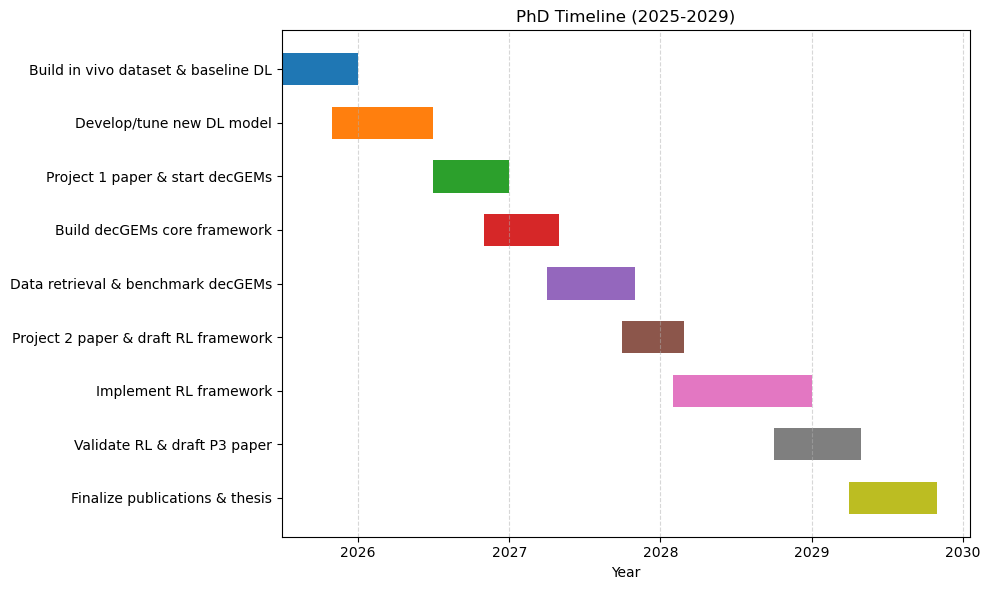

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- 1. Define the timeline ----
tasks = [
    {"Task": "Build in vivo dataset & baseline DL",      "Start": "2025-07-01", "End": "2025-12-31"},
    {"Task": "Develop/tune new DL model",                "Start": "2025-10-31", "End": "2026-06-30"},
    {"Task": "Project 1 paper & start decGEMs",           "Start": "2026-07-01", "End": "2026-12-31"},
    {"Task": "Build decGEMs core framework",             "Start": "2026-10-31", "End": "2027-04-30"},
    {"Task": "Data retrieval & benchmark decGEMs",       "Start": "2027-04-01", "End": "2027-10-31"},
    {"Task": "Project 2 paper & draft RL framework",      "Start": "2027-10-01", "End": "2028-02-28"},
    {"Task": "Implement RL framework",                   "Start": "2028-02-01", "End": "2028-12-31"},
    {"Task": "Validate RL & draft P3 paper",                "Start": "2028-10-01", "End": "2029-04-30"},
    {"Task": "Finalize publications & thesis",           "Start": "2029-04-01", "End": "2029-10-31"},
]

df = pd.DataFrame(tasks)
df["Start"] = pd.to_datetime(df["Start"])
df["End"]   = pd.to_datetime(df["End"])
df["Duration"] = (df["End"] - df["Start"]).dt.days

# ---- 2. Plot the Gantt chart ----
fig, ax = plt.subplots(figsize=(10, 6))

for idx, row in df.iterrows():
    ax.barh(idx, row["Duration"], left=row["Start"], height=0.6)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Task"])
ax.invert_yaxis()                           # first task at top
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlabel("Year")
ax.set_title("PhD Timeline (2025-2029)")
plt.tight_layout()

# ---- 3. Save / show ----
plt.savefig("timeline_gantt.png", dpi=300)  # change path if needed
plt.show()
